**Author**: Lukas Hörtnagl (holukas@ethz.ch)

<span style='font-size:40px; display:block;'>
<b>
    Separate gap-filling for 2+ weeks in 2012
</b>    
</span>

- Tricky gap in 2012
- Random forest models were not able to predict fluxes satisfactorily between 27 Feb 2012 8:00 and 16 Mar 2012 18:00
- Here MDS is used to fill this short time period
- First, the time period is removed from the *gap-filled* fluxes that were previously gap-filled with random forest
- Next, MDS is used to gap-fill the time period, using SW_IN, TS and SWC as predictors
- This produced a more realistic flux pattern during this period

</br>

# **Imports**
- This notebook uses `diive` ([source code](https://gitlab.ethz.ch/diive/diive)) to check eddy covariance fluxes for quality

In [1]:
import importlib.metadata
import datetime as dt
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.pkgs.gapfilling.mds import FluxMDS
from diive.core.plotting.cumulative import CumulativeYear
import warnings
warnings.filterwarnings('ignore')
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.87.0


# **Define variables**

## Target variable
- Needed: the fully quality-controlled flux before gap-filling
- This variable will be gap-filled

In [2]:
ustar_scenario = "CUT_50"
MEASURED_var = f"FN2O_L3.1_L3.3_{ustar_scenario}_QCF"
GAPF_var = f"{MEASURED_var}_gfRF"
FLAG_var = f'FLAG_{GAPF_var}_ISFILLED'  # Gap-filling flag, 0=measured, 1=filled best quality, 2=filled fallback option
suffix = "FN2O"
gain = 0.00050424109632  # Conversion factor to convert nmol N2O m-2 s-1 to kg N2O-N ha-1
units = r'($\mathrm{kg\ N_2O-N\ ha^{-1}}$)'  # Units for N2O flux, used in cumulative plots only

## Features

In [3]:
# Only meteo vars for MDS
METEO_VARS = [
    "TS_GF1_0.04_1_gfXG",      
    "SWC_GF1_0.15_1_gfXG",     
    "SW_IN_T1_2_1"
]

FEATURES = METEO_VARS
FEATURES

['TS_GF1_0.04_1_gfXG', 'SWC_GF1_0.15_1_gfXG', 'SW_IN_T1_2_1']

# **Load data**

## Load main data
- Contains features

In [4]:
SOURCEDIR = r"../30_MERGE_DATA"
FILENAME = r"33.5_CH-CHA_IRGA+QCL+LGR+M10+MGMT_Level-1_eddypro_fluxnet_2005-2024.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
print(f"Data will be loaded from the following file:\n{FILEPATH}")
MAIN_df = load_parquet(filepath=FILEPATH)
_locs = (MAIN_df.index.year >= 2012) & (MAIN_df.index.year <= 2012)
MAIN_df = MAIN_df[_locs].copy()
FEATURES_df = MAIN_df[FEATURES].copy()
FEATURES_df

Data will be loaded from the following file:
..\30_MERGE_DATA\33.5_CH-CHA_IRGA+QCL+LGR+M10+MGMT_Level-1_eddypro_fluxnet_2005-2024.parquet
Loaded .parquet file ..\30_MERGE_DATA\33.5_CH-CHA_IRGA+QCL+LGR+M10+MGMT_Level-1_eddypro_fluxnet_2005-2024.parquet (0.682 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,TS_GF1_0.04_1_gfXG,SWC_GF1_0.15_1_gfXG,SW_IN_T1_2_1
TIMESTAMP_MIDDLE,,,
2012-01-01 00:15:00,4.4616,47.828381,0.0
2012-01-01 00:45:00,4.4662,47.830925,0.0
2012-01-01 01:15:00,4.4702,47.838543,0.0
2012-01-01 01:45:00,4.5145,47.841091,0.0
2012-01-01 02:15:00,4.5171,47.848713,0.0
...,...,...,...
2012-12-31 21:45:00,3.7552,47.014778,0.0
2012-12-31 22:15:00,3.7072,47.015614,0.0
2012-12-31 22:45:00,3.6226,47.022266,0.0


## Load (previously corrected) gap-filled fluxes 2012
- Contains gap-filled flux and flag

In [5]:
SOURCEDIR = r""
FILENAME = r"51.3_CorrectionGapFilling_L4.1_FN2O_CUT_50.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
FLUX_df = load_parquet(filepath=FILEPATH)
_locs = (FLUX_df.index.year >= 2012) & (FLUX_df.index.year <= 2012)
FLUX_df = FLUX_df[_locs].copy()
FLUX_df

Loaded .parquet file 51.3_CorrectionGapFilling_L4.1_FN2O_CUT_50.parquet (0.047 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,FN2O,USTAR,SW_IN_POT,DAYTIME,NIGHTTIME,FLAG_L2_FN2O_MISSING_TEST,FLAG_L2_FN2O_SSITC_TEST,FLAG_L2_FN2O_COMPLETENESS_TEST,FLAG_L2_FN2O_SCF_TEST,FLAG_L2_FN2O_N2O_VM97_SPIKE_HF_TEST,FLAG_L2_FN2O_N2O_VM97_AMPLITUDE_RESOLUTION_HF_TEST,FLAG_L2_FN2O_N2O_VM97_DROPOUT_TEST,FLAG_L2_FN2O_VM97_AOA_HF_TEST,SUM_L2_FN2O_HARDFLAGS,SUM_L2_FN2O_SOFTFLAGS,...,FN2O_L3.1_L3.3_CUT_50_QCF,FN2O_L3.1_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_84_FN2O_L3.1_USTAR_TEST,SUM_L3.3_CUT_84_FN2O_L3.1_HARDFLAGS,SUM_L3.3_CUT_84_FN2O_L3.1_SOFTFLAGS,SUM_L3.3_CUT_84_FN2O_L3.1_FLAGS,FLAG_L3.3_CUT_84_FN2O_L3.1_QCF,FN2O_L3.1_L3.3_CUT_84_QCF,FN2O_L3.1_L3.3_CUT_84_QCF0,FN2O_L3.1_L3.3_CUT_16_QCF_gfRF,FLAG_FN2O_L3.1_L3.3_CUT_16_QCF_gfRF_ISFILLED,FN2O_L3.1_L3.3_CUT_50_QCF_gfRF,FLAG_FN2O_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED,FN2O_L3.1_L3.3_CUT_84_QCF_gfRF,FLAG_FN2O_L3.1_L3.3_CUT_84_QCF_gfRF_ISFILLED
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2012-01-01 00:15:00,NaN,0.191226,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,0.0,2.0,0.0,2.0,2.0,NaN,NaN,0.615439,1,1.692910,1.0,1.303387,1
2012-01-01 00:45:00,NaN,0.056639,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,0.357831,1,0.479658,1.0,0.340526,1
2012-01-01 01:15:00,NaN,0.105926,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,0.0,2.0,0.0,2.0,2.0,NaN,NaN,0.299795,1,0.349175,1.0,0.300821,1
2012-01-01 01:45:00,NaN,0.061007,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,0.547467,1,1.663710,1.0,1.312394,1
2012-01-01 02:15:00,NaN,0.079177,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,0.560168,1,1.668482,1.0,1.311202,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 21:45:00,-0.126775,0.064993,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,-0.700139,1,0.082655,1.0,0.548848,1
2012-12-31 22:15:00,0.613063,0.059460,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,-0.759284,1,0.152729,1.0,0.528988,1
2012-12-31 22:45:00,1.218430,0.058793,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,...,NaN,NaN,2.0,2.0,1.0,3.0,2.0,NaN,NaN,1.235427,0,0.165352,1.0,0.560642,1


# **Plot cumulatives**: Before

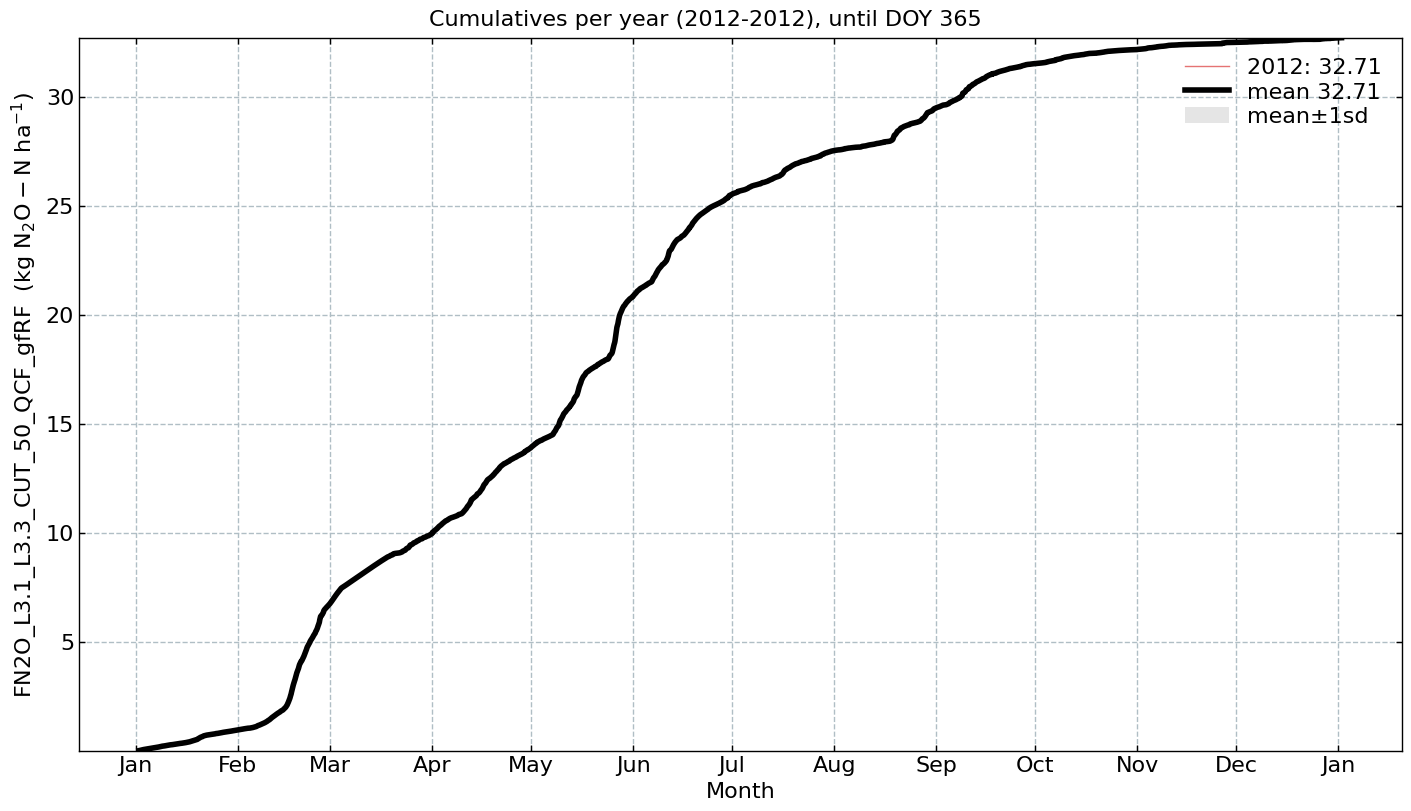

In [6]:
s = FLUX_df[GAPF_var].copy()
s = s.multiply(gain)

CumulativeYear(
    series=s,
    series_units=units,
    yearly_end_date=None,
    # yearly_end_date='08-11',
    start_year=2012,
    end_year=2014,
    show_reference=True,
    excl_years_from_reference=None,
    highlight_year=None,
    highlight_year_color='#F44336').plot()

# **Make subset for gap-filling**
- Merge gap-filled fluxes, flag and features
- Remove gap-filled values for 2017, 2018 and 2022, keep all other years

## Merge measured flux (not gap-filled) with features

In [7]:
SUBSET_df = pd.concat([FLUX_df[[GAPF_var]], FEATURES_df], axis=1)
SUBSET_df

,FN2O_L3.1_L3.3_CUT_50_QCF_gfRF,TS_GF1_0.04_1_gfXG,SWC_GF1_0.15_1_gfXG,SW_IN_T1_2_1
TIMESTAMP_MIDDLE,,,,
2012-01-01 00:15:00,1.692910,4.4616,47.828381,0.0
2012-01-01 00:45:00,0.479658,4.4662,47.830925,0.0
2012-01-01 01:15:00,0.349175,4.4702,47.838543,0.0
2012-01-01 01:45:00,1.663710,4.5145,47.841091,0.0
2012-01-01 02:15:00,1.668482,4.5171,47.848713,0.0
...,...,...,...,...
2012-12-31 21:45:00,0.082655,3.7552,47.014778,0.0
2012-12-31 22:15:00,0.152729,3.7072,47.015614,0.0
2012-12-31 22:45:00,0.165352,3.6226,47.022266,0.0


# **Remove time period**

## Identify exact start and end of problematic time period
I checked the eddy covariance raw data plots (20Hz):
- `2012022702.b00` is the last complete raw data file before the gap, N2O and CH4 look good
- `2012022708.b00` is the last complete raw data file before the gap, but N2O and CH4 measurements by the QCL are already faulty
- `2012022714.b00` is the first incomplete raw data file already *during* the gap (N2O and CH4 completely missing)
- `2012031602.b00` is the last incomplete raw data file already *during* the gap (N2O and CH4 completely missing)
- `2012031614.b00` is the first complete raw data file after the gap, N2O and CH4 look good again after approx. 18:00h
- `2012031620.b00` is the first complete raw data file after the gap, N2O and CH4 look good again

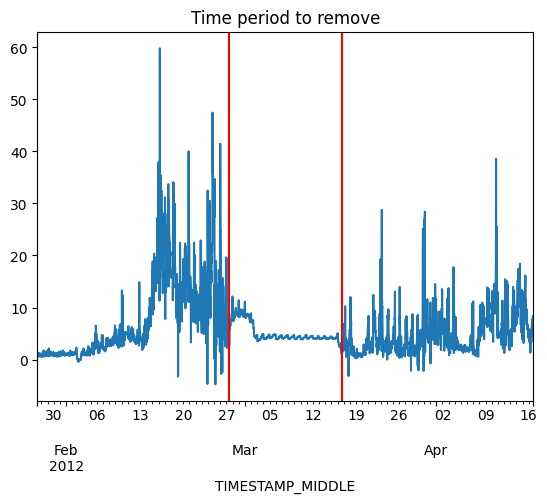

In [8]:
# Removal dates
remove_from = datetime(2012, 2, 27, 8, 0)
remove_until = datetime(2012, 3, 16, 18, 0)
replacelocs = (SUBSET_df.index >= remove_from) & (SUBSET_df.index <= remove_until)

show_locs = (SUBSET_df.index >= datetime(2012, 1, 27, 8, 0)) & (SUBSET_df.index <= datetime(2012, 4, 16, 18, 0))  # For plotting
ax = SUBSET_df[GAPF_var].loc[show_locs].plot(title="Time period to remove")
plt.axvline(remove_from, color="red")
plt.axvline(remove_until, color="red");

## Remove fluxes on dates

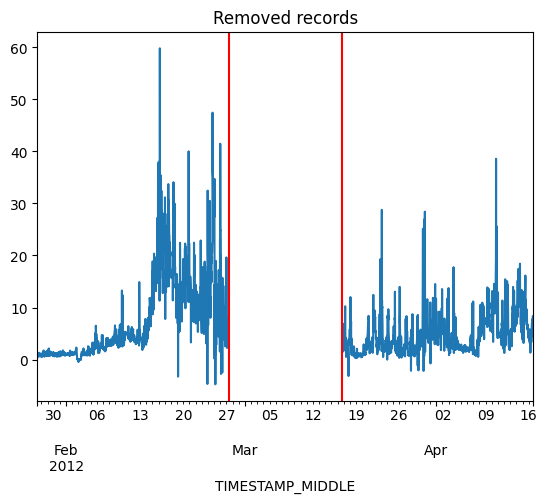

In [9]:
SUBSET_df[GAPF_var].loc[replacelocs] = np.nan
ax = SUBSET_df[GAPF_var].loc[show_locs].plot(title="Removed records")
plt.axvline(remove_from, color="red")
plt.axvline(remove_until, color="red");

# **Gap-filling**

## Run MDS


Starting MDS gap-filling of flux FN2O_L3.1_L3.3_CUT_50_QCF_gfRF.
MDS gap-filling quality 1    using SW_IN, TA, VPD in 7 days window ...
MDS gap-filling quality 2    using SW_IN, TA, VPD in 14 days window ...
MDS gap-filling quality 3    using SW_IN in 7 days window ...
MDS gap-filling quality 4    using mean diurnal cycle of flux in 0 days, 1 hours window ...
MDS gap-filling quality 5    using mean diurnal cycle of flux in 1 days, 1 hours window ...
MDS gap-filling quality 6    using SW_IN, TA, VPD in 21 days window ...
MDS gap-filling quality 7    using SW_IN, TA, VPD in 28 days window ...
MDS gap-filling quality 8    using SW_IN in 14 days window ...
MDS gap-filling quality 9    using SW_IN, TA, VPD in 35 days window ...
MDS gap-filling quality 10    using SW_IN, TA, VPD in 42 days window ...
MDS gap-filling quality 11    using SW_IN, TA, VPD in 49 days window ...
MDS gap-filling quality 12    using SW_IN, TA, VPD in 56 days window ...
MDS gap-filling quality 13    using SW_IN, TA, 

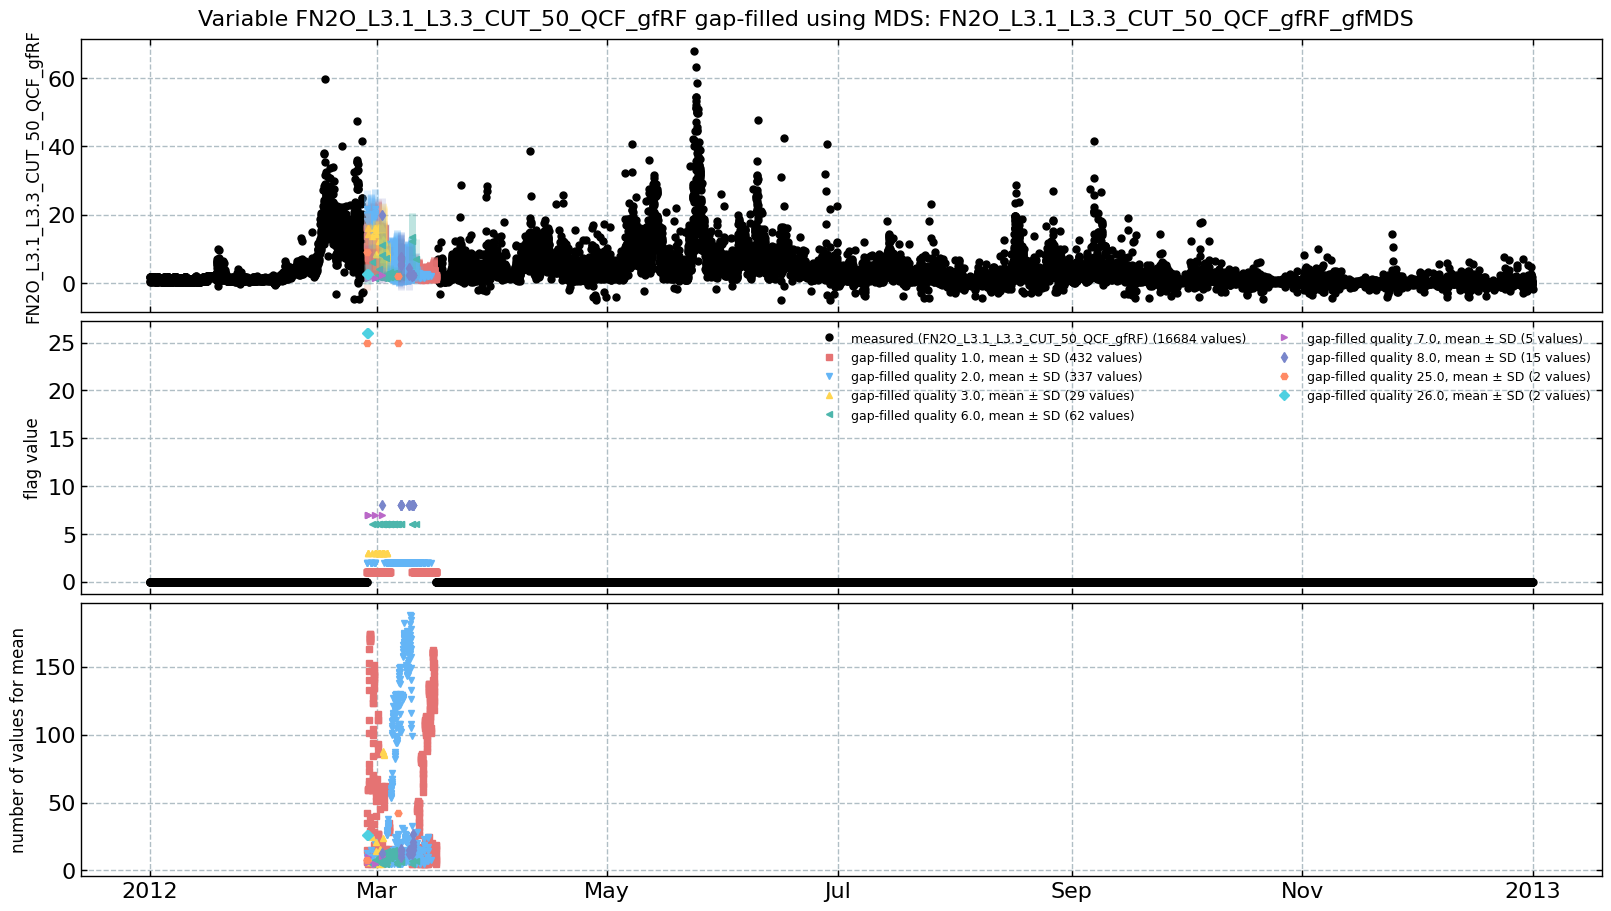

In [10]:
mds = FluxMDS(
        df=SUBSET_df,
        flux=GAPF_var,
        ta='TS_GF1_0.04_1_gfXG',
        swin='SW_IN_T1_2_1',
        vpd='SWC_GF1_0.15_1_gfXG',
        swin_tol=[20, 50],
        ta_tol=2.5,
        vpd_tol=2.5,
        avg_min_n_vals=5
    )
mds.run()
mds.report()
mds.showplot()
print(mds.gapfilling_df_)

## Result
- new gap-filled fluxes

In [11]:
var_new_gapfilled = mds.get_gapfilled_target().name
var_new_flag = mds.get_flag().name
new_gapfilling_df = mds.gapfilling_df_
# new_gapfilling_df = new_gapfilling_df[[var_new_gapfilled, var_new_flag]]
new_gapfilling_df.describe()

,FN2O_L3.1_L3.3_CUT_50_QCF_gfRF,SW_IN_T1_2_1,TS_GF1_0.04_1_gfXG,SWC_GF1_0.15_1_gfXG,.TIMESTAMP,FN2O_L3.1_L3.3_CUT_50_QCF_gfRF_gfMDS,FLAG_FN2O_L3.1_L3.3_CUT_50_QCF_gfRF_gfMDS_ISFILLED,.PREDICTIONS,.PREDICTIONS_SD,.PREDICTIONS_COUNTS,.PREDICTIONS_QUALITY,.START,.END,.SW_IN_T1_2_1_LOWERLIM,.SW_IN_T1_2_1_UPPERLIM,.TS_GF1_0.04_1_gfXG_LOWERLIM,.TS_GF1_0.04_1_gfXG_UPPERLIM,.SWC_GF1_0.15_1_gfXG_LOWERLIM,.SWC_GF1_0.15_1_gfXG_UPPERLIM
count,16684.000000,17568.000000,17568.000000,17568.000000,17568,17568.000000,17568.000000,17568.000000,17568.000000,17568.000000,17568.000000,17568,17568,17568.000000,17568.000000,17568.000000,17568.000000,17568.000000,17568.000000
mean,3.621252,142.896565,11.656765,45.417759,2012-07-02 00:00:00,3.723052,0.103711,3.729869,2.777508,179.147883,1.061191,2012-06-24 18:57:01.311475456,2012-07-09 05:02:58.688524544,111.112070,174.681059,9.156765,14.156765,42.917759,47.917759
min,-4.897182,0.000000,-1.276711,37.052464,2012-01-01 00:15:00,-4.897182,0.000000,-0.572653,0.171464,5.000000,1.000000,2011-12-25 00:15:00,2012-01-08 00:15:00,-20.000000,20.000000,-3.776711,1.223289,34.552464,39.552464
25%,0.674205,0.000000,5.002475,44.156847,2012-04-01 12:07:30,0.726595,0.000000,1.005773,0.912835,31.000000,1.000000,2012-03-25 12:07:30,2012-04-08 12:07:30,-20.000000,20.000000,2.502475,7.502475,41.656847,46.656847
50%,1.820002,0.000000,11.814000,45.889500,2012-07-02 00:00:00,1.940143,0.000000,2.542237,1.839252,145.000000,1.000000,2012-06-25 00:00:00,2012-07-09 00:00:00,-20.000000,20.000000,9.314000,14.314000,43.389500,48.389500
75%,4.512645,188.642506,17.809250,46.979073,2012-10-01 11:52:30,4.694627,0.000000,5.471380,3.882407,304.000000,1.000000,2012-09-24 11:52:30,2012-10-08 11:52:30,138.642506,238.642506,15.309250,20.309250,44.479073,49.479073
max,67.838850,1084.900024,25.462999,48.714169,2012-12-31 23:45:00,67.838850,26.000000,37.623631,19.595689,530.000000,26.000000,2012-12-24 23:45:00,2013-01-07 23:45:00,1034.900024,1134.900024,22.962999,27.962999,46.214169,51.214169
std,5.249432,238.245679,6.955330,2.130927,NaN,5.218963,0.670221,3.722410,2.515374,154.990155,0.560417,NaN,NaN,227.830712,249.087373,6.955330,6.955330,2.130927,2.130927


# Check new gap-filling

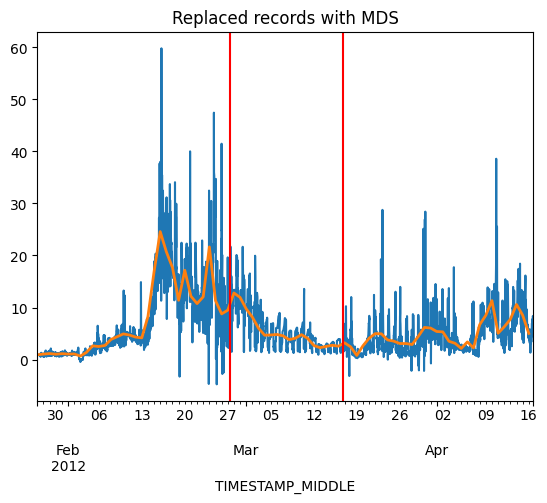

In [12]:
ax = new_gapfilling_df[var_new_gapfilled].loc[show_locs].plot(title="Replaced records with MDS")
ax = new_gapfilling_df[var_new_gapfilled].loc[show_locs].resample('D').mean().plot(title="Replaced records with MDS", lw=2)
plt.axvline(remove_from, color="red")
plt.axvline(remove_until, color="red");

</br>

# Comparison heatmaps

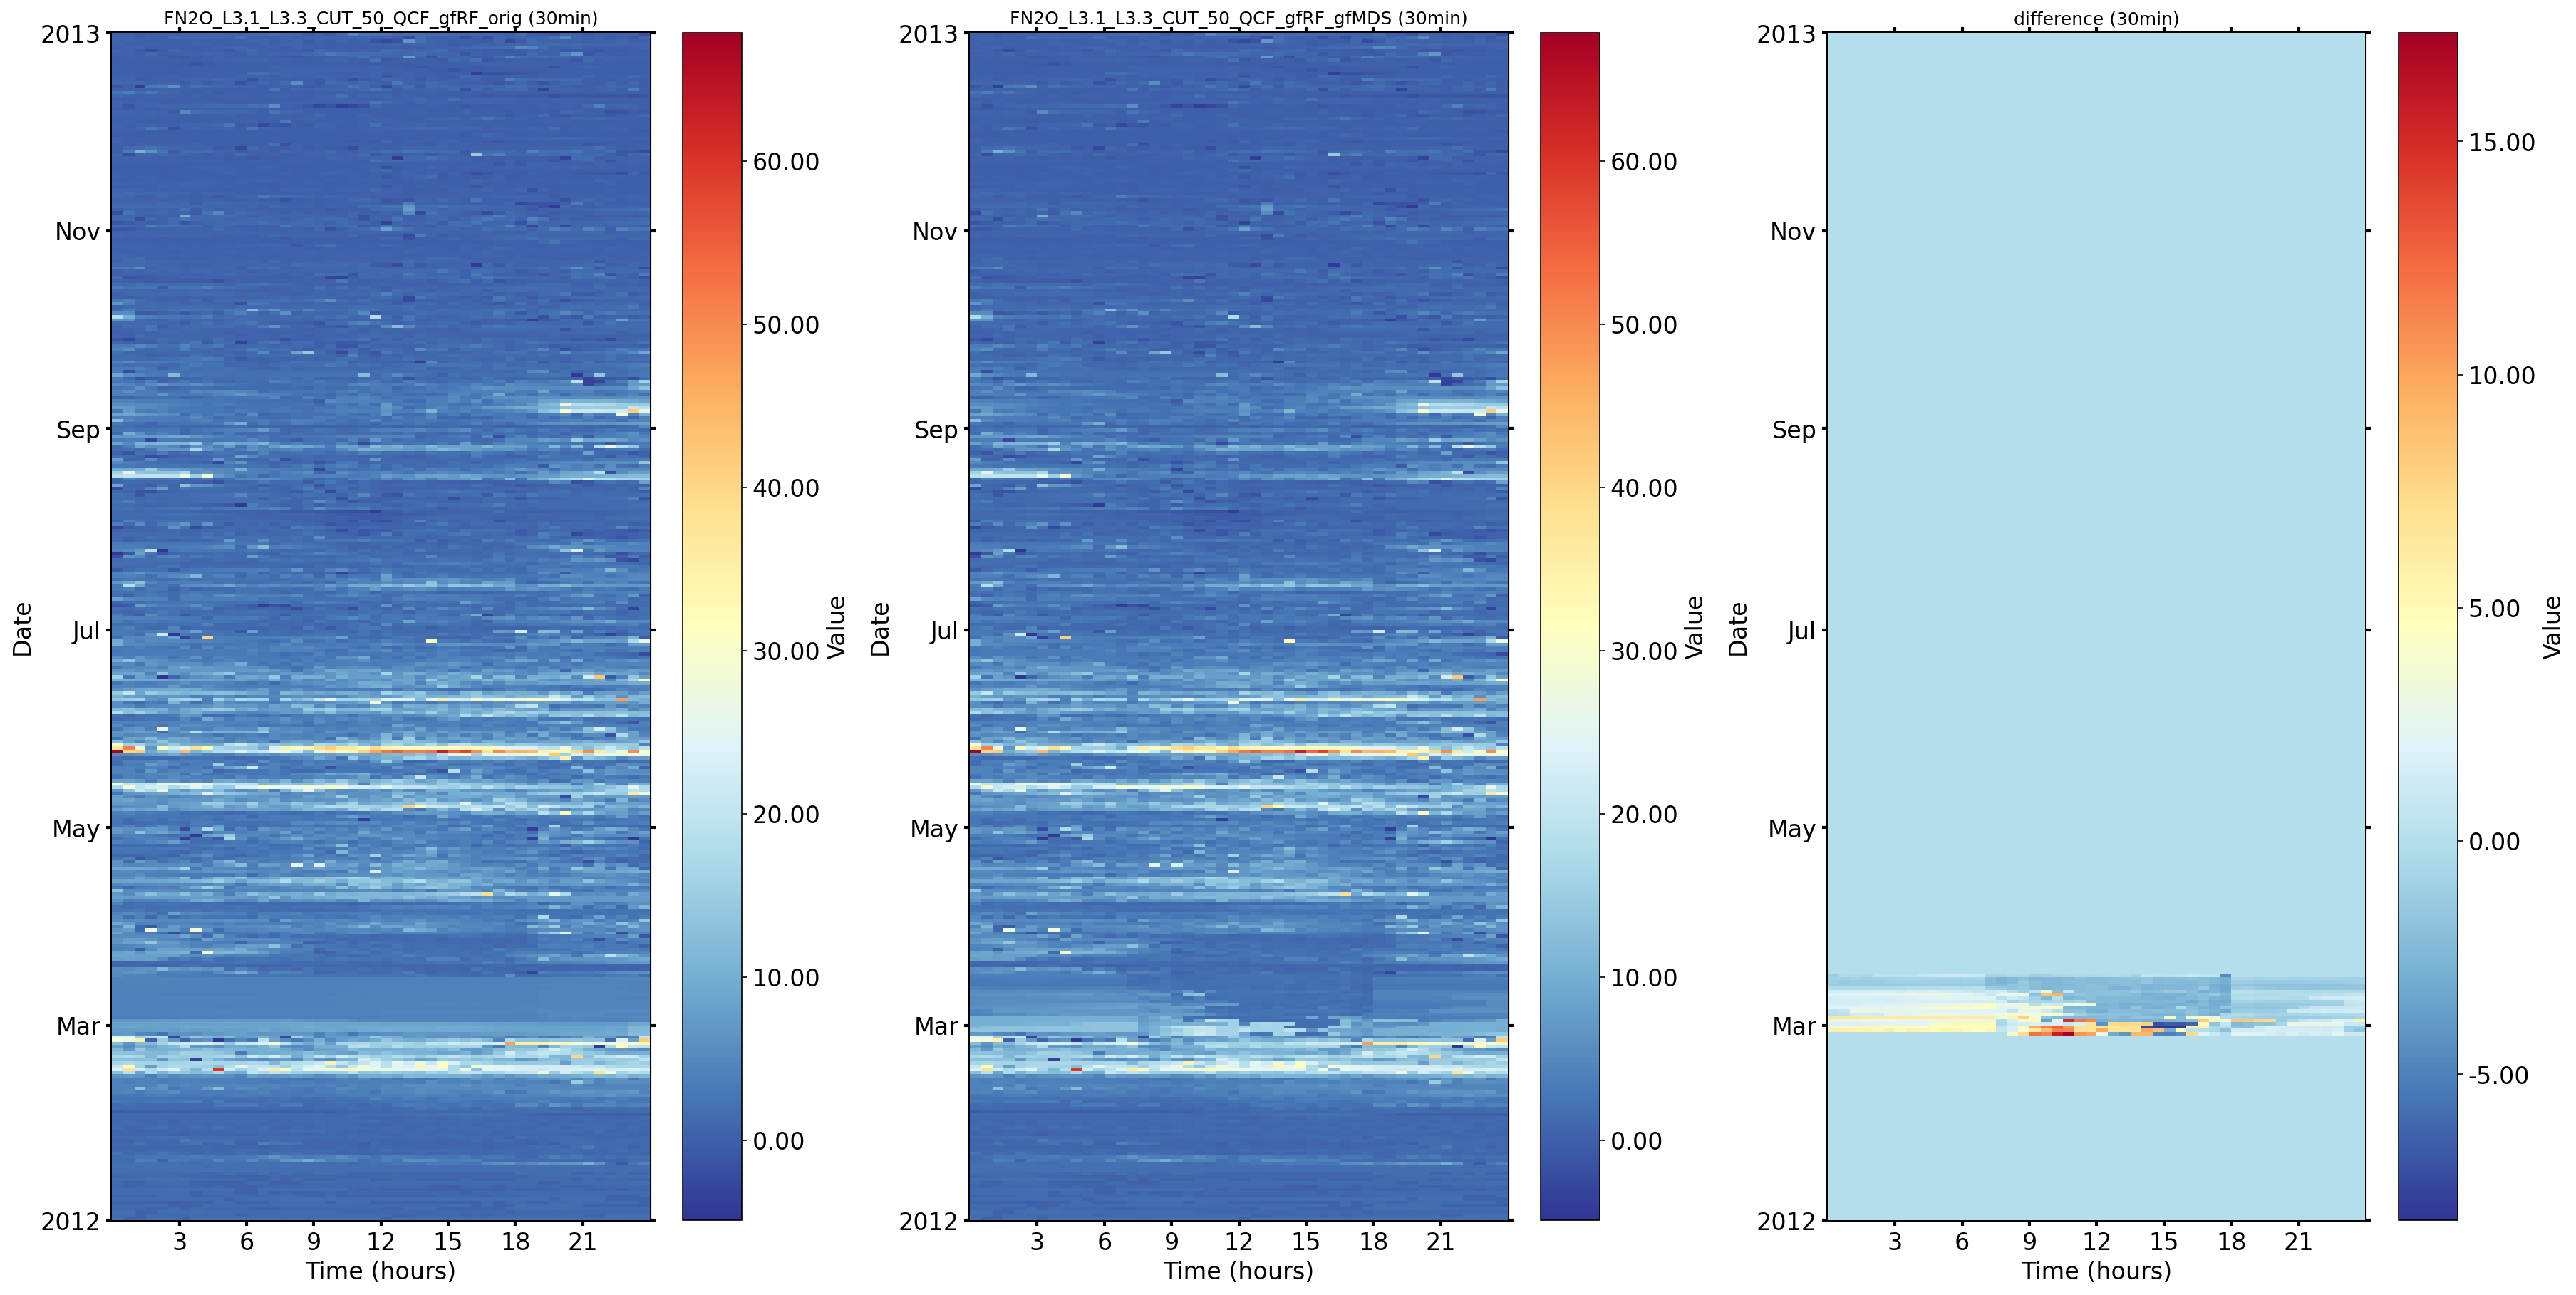

In [15]:
# Store previously gap-filled flux For comparison
flux_gapfilled_orig = FLUX_df[GAPF_var].copy()  
flux_gapfilled_orig.name = f"{GAPF_var}_orig"

diff = new_gapfilling_df[var_new_gapfilled].sub(flux_gapfilled_orig)
diff.name = "difference"

fig, axs = plt.subplots(ncols=3, figsize=(24, 12), dpi=150, layout="constrained")
HeatmapDateTime(series=flux_gapfilled_orig, ax=axs[0]).plot()  # Gap-filled flux from previous gap-filling
HeatmapDateTime(series=new_gapfilling_df[var_new_gapfilled], ax=axs[1]).plot()  # New gap-filling
HeatmapDateTime(series=diff, ax=axs[2]).plot()  # Difference between previous gap-filling and new gap-filling, to check if it worked for the three years

# **Add 2+ weeks back to main data**

In [16]:
FLUX_df.loc[replacelocs, GAPF_var]

TIMESTAMP_MIDDLE
2012-02-27 08:15:00    6.688889
2012-02-27 08:45:00    6.556973
2012-02-27 09:15:00    4.094020
2012-02-27 09:45:00    6.770833
2012-02-27 10:15:00    6.132902
                         ...   
2012-03-16 15:45:00    1.285254
2012-03-16 16:15:00    0.982911
2012-03-16 16:45:00    1.570397
2012-03-16 17:15:00    1.315019
2012-03-16 17:45:00    5.798743
Freq: 30min, Name: FN2O_L3.1_L3.3_CUT_50_QCF_gfRF, Length: 884, dtype: float64

## Remove records from previous gap-filling

In [17]:
FLUX_df.loc[replacelocs, GAPF_var] = np.nan
FLUX_df.loc[replacelocs, FLAG_var] = np.nan
FLUX_df.loc[replacelocs, GAPF_var]

TIMESTAMP_MIDDLE
2012-02-27 08:15:00   NaN
2012-02-27 08:45:00   NaN
2012-02-27 09:15:00   NaN
2012-02-27 09:45:00   NaN
2012-02-27 10:15:00   NaN
                       ..
2012-03-16 15:45:00   NaN
2012-03-16 16:15:00   NaN
2012-03-16 16:45:00   NaN
2012-03-16 17:15:00   NaN
2012-03-16 17:45:00   NaN
Freq: 30min, Name: FN2O_L3.1_L3.3_CUT_50_QCF_gfRF, Length: 884, dtype: float64

## Fill new gap-filling into gaps

In [18]:
FLUX_df.loc[replacelocs, GAPF_var] = new_gapfilling_df.loc[replacelocs, var_new_gapfilled]
FLUX_df.loc[replacelocs, FLAG_var] = new_gapfilling_df.loc[replacelocs, var_new_flag]
FLUX_df.loc[replacelocs, GAPF_var]

TIMESTAMP_MIDDLE
2012-02-27 08:15:00    10.753529
2012-02-27 08:45:00    13.824061
2012-02-27 09:15:00    16.166679
2012-02-27 09:45:00    18.041512
2012-02-27 10:15:00    21.725406
                         ...    
2012-03-16 15:45:00     1.789047
2012-03-16 16:15:00     1.915664
2012-03-16 16:45:00     2.206282
2012-03-16 17:15:00     1.820307
2012-03-16 17:45:00     1.246929
Freq: 30min, Name: FN2O_L3.1_L3.3_CUT_50_QCF_gfRF, Length: 884, dtype: float64

## Plot heatmaps

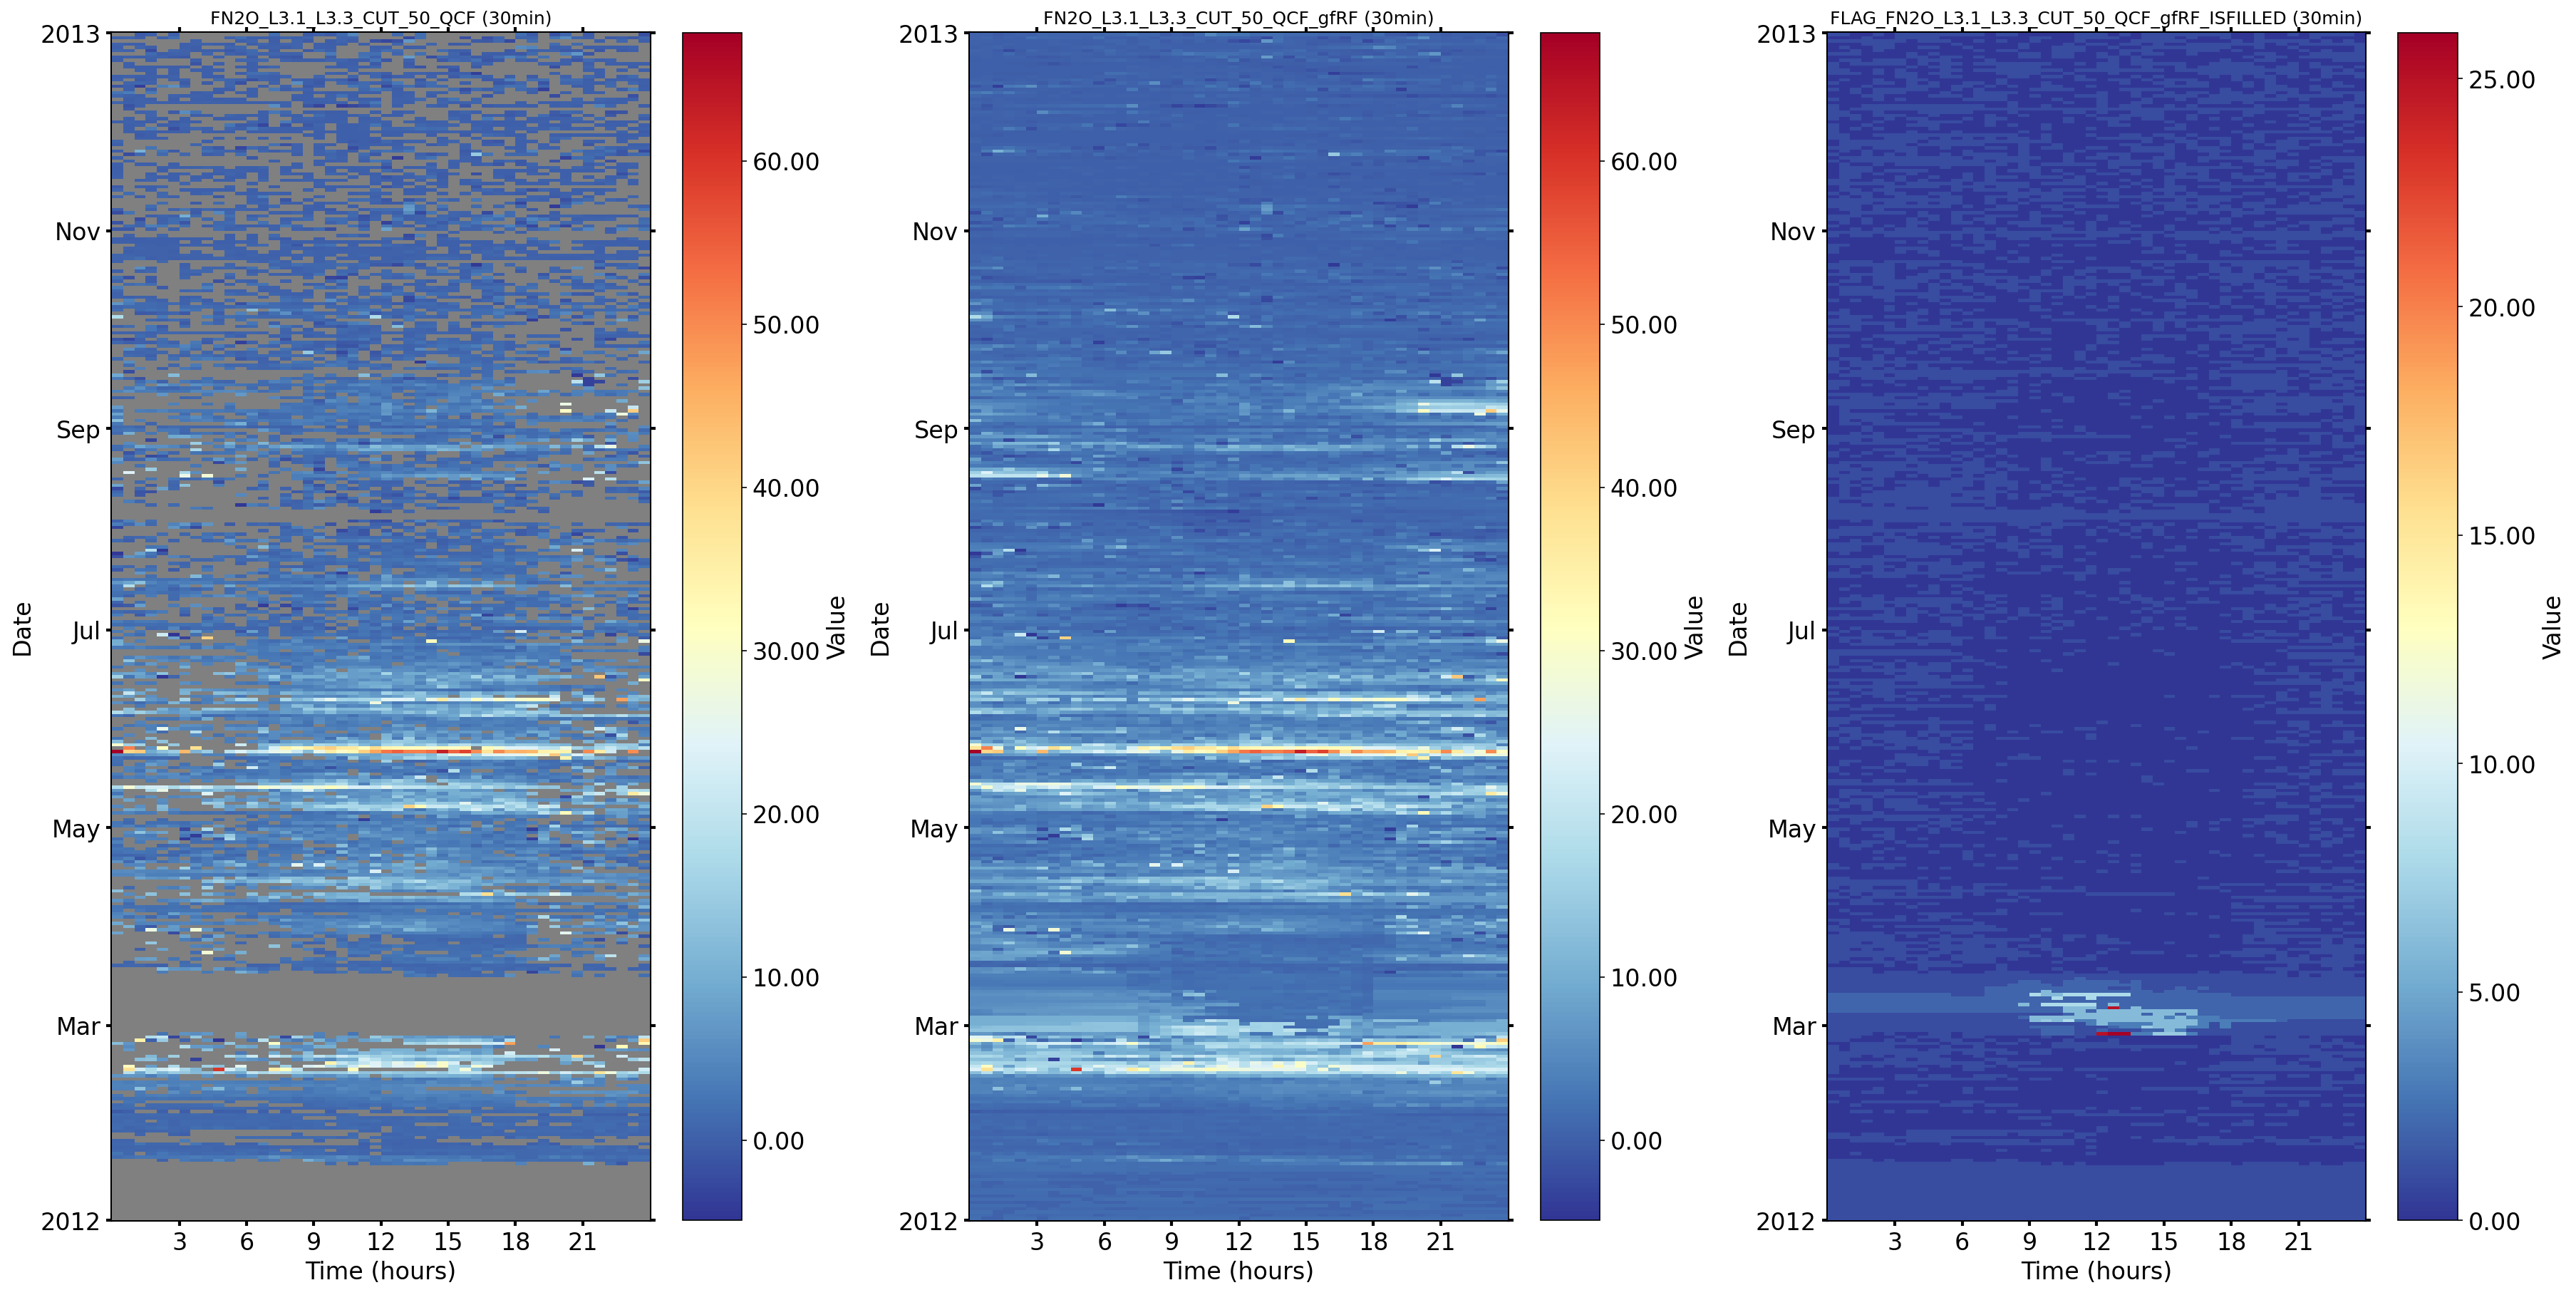

In [20]:
fig, axs = plt.subplots(ncols=3, figsize=(24, 12), dpi=150, layout="constrained")
HeatmapDateTime(series=FLUX_df[MEASURED_var], ax=axs[0]).plot()  # Originally measured data
HeatmapDateTime(series=FLUX_df[GAPF_var], ax=axs[1]).plot()  # New gap-filling in the three years
HeatmapDateTime(series=FLUX_df[FLAG_var], ax=axs[2]).plot()  #  Different scaling! Shows where OLD was replaced with NEW

# **Plot cumulatives**: After

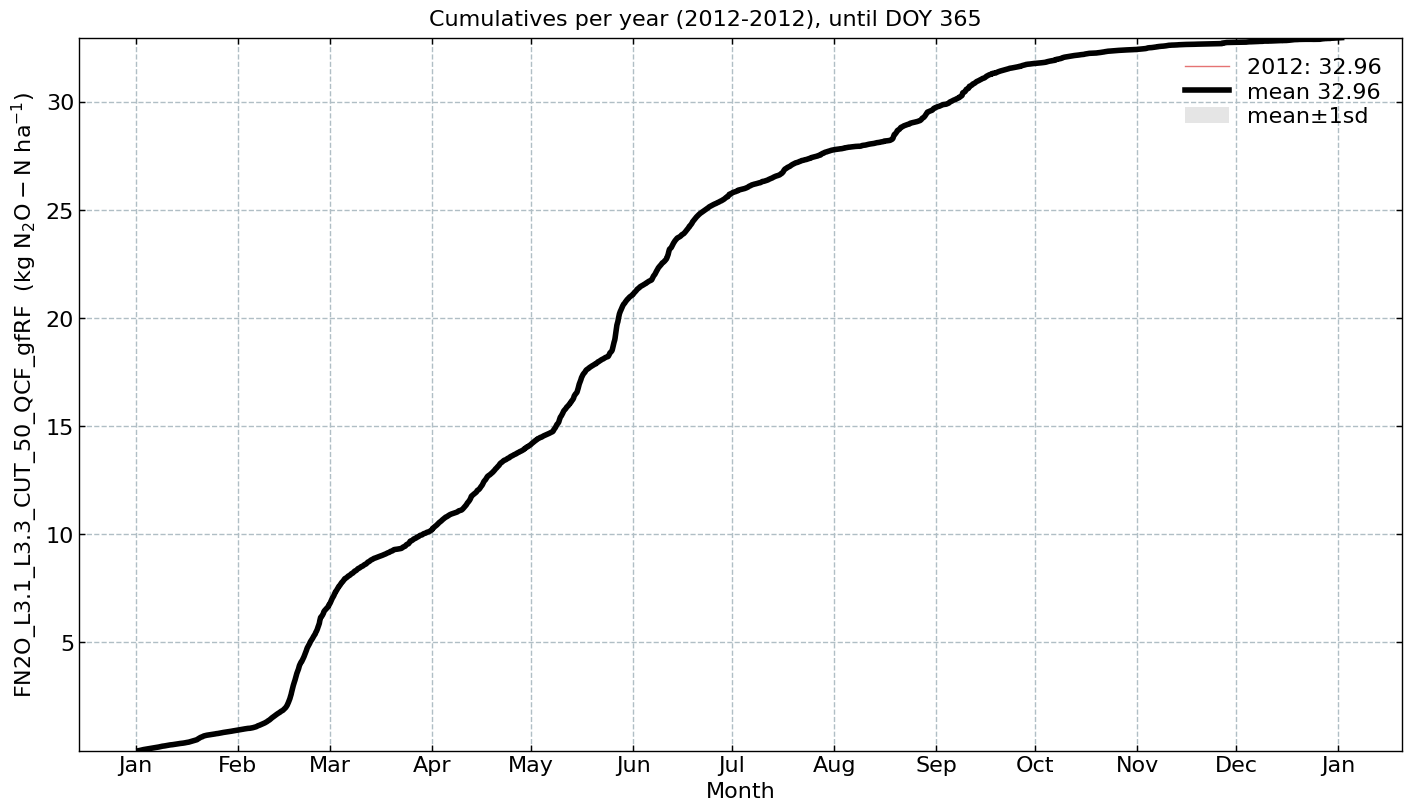

In [21]:
s = FLUX_df[GAPF_var].copy()
s = s.multiply(gain)

CumulativeYear(
    series=s,
    series_units=units,
    yearly_end_date=None,
    # yearly_end_date='08-11',
    start_year=2012,
    end_year=2022,
    show_reference=True,
    excl_years_from_reference=None,
    highlight_year=None,
    highlight_year_color='#F44336').plot()

# **Save to file**

In [22]:
FLUX_df

,FN2O,USTAR,SW_IN_POT,DAYTIME,NIGHTTIME,FLAG_L2_FN2O_MISSING_TEST,FLAG_L2_FN2O_SSITC_TEST,FLAG_L2_FN2O_COMPLETENESS_TEST,FLAG_L2_FN2O_SCF_TEST,FLAG_L2_FN2O_N2O_VM97_SPIKE_HF_TEST,FLAG_L2_FN2O_N2O_VM97_AMPLITUDE_RESOLUTION_HF_TEST,FLAG_L2_FN2O_N2O_VM97_DROPOUT_TEST,FLAG_L2_FN2O_VM97_AOA_HF_TEST,SUM_L2_FN2O_HARDFLAGS,SUM_L2_FN2O_SOFTFLAGS,...,FN2O_L3.1_L3.3_CUT_50_QCF,FN2O_L3.1_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_84_FN2O_L3.1_USTAR_TEST,SUM_L3.3_CUT_84_FN2O_L3.1_HARDFLAGS,SUM_L3.3_CUT_84_FN2O_L3.1_SOFTFLAGS,SUM_L3.3_CUT_84_FN2O_L3.1_FLAGS,FLAG_L3.3_CUT_84_FN2O_L3.1_QCF,FN2O_L3.1_L3.3_CUT_84_QCF,FN2O_L3.1_L3.3_CUT_84_QCF0,FN2O_L3.1_L3.3_CUT_16_QCF_gfRF,FLAG_FN2O_L3.1_L3.3_CUT_16_QCF_gfRF_ISFILLED,FN2O_L3.1_L3.3_CUT_50_QCF_gfRF,FLAG_FN2O_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED,FN2O_L3.1_L3.3_CUT_84_QCF_gfRF,FLAG_FN2O_L3.1_L3.3_CUT_84_QCF_gfRF_ISFILLED
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2012-01-01 00:15:00,NaN,0.191226,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,0.0,2.0,0.0,2.0,2.0,NaN,NaN,0.615439,1,1.692910,1.0,1.303387,1
2012-01-01 00:45:00,NaN,0.056639,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,0.357831,1,0.479658,1.0,0.340526,1
2012-01-01 01:15:00,NaN,0.105926,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,0.0,2.0,0.0,2.0,2.0,NaN,NaN,0.299795,1,0.349175,1.0,0.300821,1
2012-01-01 01:45:00,NaN,0.061007,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,0.547467,1,1.663710,1.0,1.312394,1
2012-01-01 02:15:00,NaN,0.079177,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,0.560168,1,1.668482,1.0,1.311202,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 21:45:00,-0.126775,0.064993,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,-0.700139,1,0.082655,1.0,0.548848,1
2012-12-31 22:15:00,0.613063,0.059460,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,-0.759284,1,0.152729,1.0,0.528988,1
2012-12-31 22:45:00,1.218430,0.058793,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,...,NaN,NaN,2.0,2.0,1.0,3.0,2.0,NaN,NaN,1.235427,0,0.165352,1.0,0.560642,1


In [23]:
outfile = f"51.3b_CorrectionGapFilling_L4.1_{suffix}_{ustar_scenario}"
# FLUX_df.to_csv(f"{outfile}.csv")  # large file, slow to read
save_parquet(data=FLUX_df, filename=f"{outfile}")  # Smaller file, very fast to read

Saved file 51.3b_CorrectionGapFilling_L4.1_FN2O_CUT_50.parquet (0.062 seconds).


'51.3b_CorrectionGapFilling_L4.1_FN2O_CUT_50.parquet'

# **End of notebook**
Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [24]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-05-15 16:21:39
